In [1]:
import pandas as pd
eventlog = pd.read_csv("../../data/processed/CTB/s6_eventlog_with_performance_targets.csv"
)

In [2]:
eventlog.groupby(
    pd.cut(
        eventlog["target_demand"],
        bins=5
    )
)["service_time"].mean()

target_demand
(-0.0199, 3.98]    3.801811
(3.98, 7.96]       4.285631
(7.96, 11.94]      4.020412
(11.94, 15.92]     3.354964
(15.92, 19.9]      2.763975
Name: service_time, dtype: float64

In [3]:
eventlog.groupby(
    pd.cut(
        eventlog["target_utilization"],
        bins=5
    )
)["service_time"].mean()

target_utilization
(0.00166, 0.17]    3.167421
(0.17, 0.337]      4.002863
(0.337, 0.504]     4.042253
(0.504, 0.671]     3.981938
(0.671, 0.838]     4.182710
Name: service_time, dtype: float64

In [4]:
eventlog.groupby(

    pd.qcut(
        eventlog["target_utilization"],
        5
    )

)["waiting_time"].mean()

target_utilization
(0.0015, 0.516]    6.486627
(0.516, 0.612]     6.222765
(0.612, 0.67]      6.282375
(0.67, 0.72]       6.486354
(0.72, 0.838]      6.245976
Name: waiting_time, dtype: float64

In [5]:
df = eventlog
df.groupby(

    pd.qcut(
        df["target_demand"],
        5
    )

)["waiting_time"].mean()

target_demand
(-0.001, 3.13]    4.813814
(3.13, 5.05]      6.142170
(5.05, 6.75]      6.554336
(6.75, 8.58]      6.889355
(8.58, 19.9]      7.329033
Name: waiting_time, dtype: float64

In [6]:
df.groupby(

    pd.qcut(
        df["target_utilization"],
        5
    )

)["service_time"].mean()

target_utilization
(0.0015, 0.516]    3.997791
(0.516, 0.612]     4.013730
(0.612, 0.67]      3.964957
(0.67, 0.72]       3.940718
(0.72, 0.838]      4.418149
Name: service_time, dtype: float64

In [7]:
eventlog.groupby(
    pd.cut(
        eventlog["visit_complexity"],
        bins=5
    )
)["service_time"].mean()

visit_complexity
(1.976, 6.8]    3.629145
(6.8, 11.6]     4.589431
(11.6, 16.4]    5.906193
(16.4, 21.2]    5.244842
(21.2, 26.0]    7.277778
Name: service_time, dtype: float64

RMG_RECEIVE

In [8]:
receive = df[
    df["concept:name"] == "RMG_receive"
]

receive.groupby(

    pd.qcut(
        receive["target_utilization"],
        5,
        duplicates="drop"
    )

)["waiting_time"].mean()


target_utilization
(0.0294, 0.524]    8.804986
(0.524, 0.62]      8.376971
(0.62, 0.674]      7.553289
(0.674, 0.723]     6.440499
(0.723, 0.836]     7.088508
Name: waiting_time, dtype: float64

In [9]:
receive.groupby(

    pd.qcut(
        receive["target_utilization"],
        5,
        duplicates="drop"
    )

)["service_time"].mean()

target_utilization
(0.0294, 0.524]    11.589730
(0.524, 0.62]      11.688175
(0.62, 0.674]      12.159989
(0.674, 0.723]     11.785020
(0.723, 0.836]     12.983487
Name: service_time, dtype: float64

DELIVER

In [13]:
delivery = df[
    df["concept:name"] == "RMG_delivery"
]

delivery.groupby(

    pd.qcut(
        delivery["target_utilization"],
        5,
        duplicates="drop"
    )

)["waiting_time"].mean()


target_utilization
(0.0015, 0.495]    7.425617
(0.495, 0.595]     6.330902
(0.595, 0.653]     6.073980
(0.653, 0.707]     5.651353
(0.707, 0.831]     5.307990
Name: waiting_time, dtype: float64

In [14]:
delivery.groupby(

    pd.qcut(
        delivery["target_utilization"],
        5,
        duplicates="drop"
    )

)["service_time"].mean()

target_utilization
(0.0015, 0.495]    10.357929
(0.495, 0.595]      9.350104
(0.595, 0.653]      7.715689
(0.653, 0.707]      7.607493
(0.707, 0.831]      8.035480
Name: service_time, dtype: float64

MIXED

In [15]:
mixed = df[
    df["concept:name"] == "RMG_mixed"
]

mixed.groupby(

    pd.qcut(
        mixed["target_utilization"],
        5,
        duplicates="drop"
    )

)["waiting_time"].mean()

target_utilization
(0.0023, 0.518]    8.344472
(0.518, 0.613]     9.098361
(0.613, 0.674]     7.236241
(0.674, 0.727]     7.155141
(0.727, 0.838]     6.694549
Name: waiting_time, dtype: float64

UTILIZATION X DEMAND

In [16]:
heatmap_wait = pd.pivot_table(

    df[
        df["concept:name"].isin(
            [
                "RMG_receive",
                "RMG_delivery",
                "RMG_mixed"
            ]
        )
    ],

    values="waiting_time",

    index=pd.qcut(
        df["target_utilization"],
        5,
        duplicates="drop"
    ),

    columns=pd.qcut(
        df["target_demand"],
        5,
        duplicates="drop"
    ),

    aggfunc="mean"

)

heatmap_wait


target_demand,"(-0.001, 3.13]","(3.13, 5.05]","(5.05, 6.75]","(6.75, 8.58]","(8.58, 19.9]"
target_utilization,,,,,
"(0.0015, 0.516]",4.425927,6.188692,7.777103,10.621392,15.014909
"(0.516, 0.612]",4.596342,7.142136,7.576819,8.814314,11.347484
"(0.612, 0.67]",4.044476,6.308238,6.607591,8.436448,9.734550
"(0.67, 0.72]",3.084850,5.649447,6.202052,7.110096,9.253915
"(0.72, 0.838]",4.463819,4.963465,6.424622,8.005736,8.802585


In [17]:
heatmap_service = pd.pivot_table(

    df[
        df["concept:name"].isin(
            [
                "RMG_receive",
                "RMG_delivery",
                "RMG_mixed"
            ]
        )
    ],

    values="service_time",

    index=pd.qcut(
        df["target_utilization"],
        5,
        duplicates="drop"
    ),

    columns=pd.qcut(
        df["target_demand"],
        5,
        duplicates="drop"
    ),

    aggfunc="mean"

)

heatmap_service

target_demand,"(-0.001, 3.13]","(3.13, 5.05]","(5.05, 6.75]","(6.75, 8.58]","(8.58, 19.9]"
target_utilization,,,,,
"(0.0015, 0.516]",10.363764,11.943280,12.317922,12.306866,10.823505
"(0.516, 0.612]",9.722658,11.998835,12.855734,12.254251,10.820726
"(0.612, 0.67]",9.319758,11.674639,12.070017,12.229637,11.421687
"(0.67, 0.72]",9.137537,11.491422,12.262158,12.319527,11.112402
"(0.72, 0.838]",10.391457,13.150980,13.312395,13.568112,12.172644


In [18]:
pd.pivot_table(

    df[
        df["concept:name"].isin(
            [
                "RMG_receive",
                "RMG_delivery",
                "RMG_mixed"
            ]
        )
    ],

    values="service_time",

    index=pd.qcut(
        df["visit_complexity"],
        5,
        duplicates="drop"
    ),

    columns=pd.qcut(
        df["target_utilization"],
        5,
        duplicates="drop"
    ),

    aggfunc="mean"

)

target_utilization,"(0.0015, 0.516]","(0.516, 0.612]","(0.612, 0.67]","(0.67, 0.72]","(0.72, 0.838]"
visit_complexity,,,,,
"(1.999, 4.0]",11.279204,10.504764,9.929899,9.513323,10.288255
"(4.0, 5.0]",11.209258,11.333333,11.397468,11.564895,12.867373
"(5.0, 10.0]",10.911243,10.886437,10.847561,10.850625,11.519042
"(10.0, 28.0]",12.732919,14.443272,14.723368,14.246333,15.981488


VISIT COMPLEXITY X TARGET DEMAND

In [19]:
pd.pivot_table(

    df[
        df["concept:name"].isin(
            [
                "RMG_receive",
                "RMG_delivery",
                "RMG_mixed"
            ]
        )
    ],

    values="waiting_time",

    index=pd.qcut(
        df["visit_complexity"],
        5,
        duplicates="drop"
    ),

    columns=pd.qcut(
        df["target_demand"],
        5
    ),

    aggfunc="mean"

)

target_demand,"(-0.001, 3.13]","(3.13, 5.05]","(5.05, 6.75]","(6.75, 8.58]","(8.58, 19.9]"
visit_complexity,,,,,
"(1.999, 4.0]",4.205644,5.415876,6.311037,8.007715,10.122649
"(4.0, 5.0]",3.796594,6.213229,6.727471,8.482922,10.807465
"(5.0, 10.0]",4.427808,6.356949,7.398991,8.849063,12.046487
"(10.0, 28.0]",4.565305,6.524762,7.639738,9.235891,11.656599


In [20]:
features = [

    "target_utilization",
    "target_demand",
    "visit_complexity",
    "n_containers",
    "n_receives",
    "n_deliveries"

]

df[
    features +
    [
        "waiting_time",
        "service_time"
    ]
].corr()


,target_utilization,target_demand,visit_complexity,n_containers,n_receives,n_deliveries,waiting_time,service_time
target_utilization,1.000000,0.057001,0.060448,0.019228,0.072971,-0.067201,-0.003490,0.011067
target_demand,0.057001,1.000000,-0.094573,-0.086074,-0.178873,0.070611,0.061888,0.003427
visit_complexity,0.060448,-0.094573,1.000000,0.710736,0.603261,0.499222,0.007615,0.077714
n_containers,0.019228,-0.086074,0.710736,1.000000,0.369769,0.594350,-0.003842,0.093850
n_receives,0.072971,-0.178873,0.603261,0.369769,1.000000,-0.259192,0.035706,0.084468
n_deliveries,-0.067201,0.070611,0.499222,0.594350,-0.259192,1.000000,-0.033629,0.013349
waiting_time,-0.003490,0.061888,0.007615,-0.003842,0.035706,-0.033629,1.000000,0.102007
service_time,0.011067,0.003427,0.077714,0.093850,0.084468,0.013349,0.102007,1.000000


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

In [22]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

features = [

    "target_utilization",
    "target_demand",
    "visit_complexity",
    "n_containers",
    "n_receives",
    "n_deliveries"

]

rmg = df[
    df["concept:name"].isin(
        [
            "RMG_receive",
            "RMG_delivery",
            "RMG_mixed"
        ]
    )
].copy()

X = rmg[features]

y = rmg["service_time"]

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

print(importance)

target_utilization    0.497717
target_demand         0.364466
visit_complexity      0.075544
n_receives            0.030439
n_containers          0.018566
n_deliveries          0.013268
dtype: float64


In [23]:
rf.fit(X, y)

pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

target_utilization    0.497717
target_demand         0.364466
visit_complexity      0.075544
n_receives            0.030439
n_containers          0.018566
n_deliveries          0.013268
dtype: float64

In [24]:
case_df = (

    rmg

    .groupby(
        "case:concept:name"
    )

    .first()

)

X = case_df[features]

y = case_df["waiting_time"]

In [25]:
rf.fit(X, y)

pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

target_utilization    0.518861
target_demand         0.349925
visit_complexity      0.083752
n_deliveries          0.018145
n_receives            0.015210
n_containers          0.014107
dtype: float64

In [26]:
from sklearn.metrics import r2_score

pred = rf.predict(X)

print(
    r2_score(
        y,
        pred
    )
)

0.8629466275926181


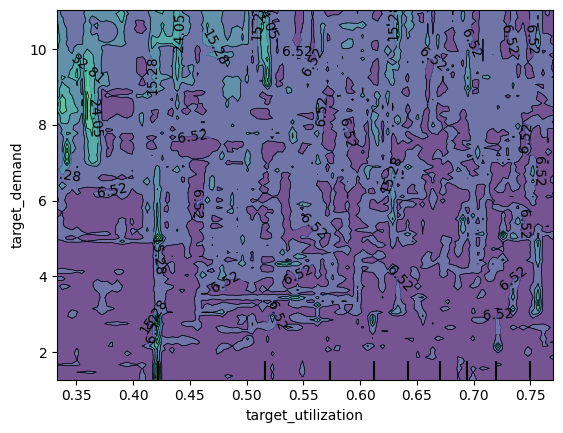

In [27]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(

    rf,

    X,

    [

        (
            "target_utilization",
            "target_demand"
        )

    ]

)